## 1. Environment Setup and Data Loading

This section imports all the libraries required throughout 
the project and loads the dataset into memory.

**Libraries used:**
- `pandas` - data manipulation and analysis
- `numpy` - numerical computations
- `matplotlib` / `seaborn` - data visualisation
- `datetime` - date and time calculations

The dataset (`Risk.csv`) contains **30,000 online purchase 
orders** with **44 attributes** each. The target variable 
`CLASS` indicates whether an order is high risk (`yes`) 
or low risk (`no`) for payment default.

A safety backup `df_backup` is created immediately after 
loading. This preserves the original data so we can 
recover from any accidental modifications during cleaning.

In [ ]:
# Import Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime # datetime is needed later for age and date calculations
%matplotlib inline

# Load the dataset
df = pd.read_csv("/Users/ade/Desktop/Logistic Regression/Default Risk Prediction/Risk.csv")

# Create a safetry backup beforre making any changes to the dataset
# If df gets broken at any point, we recover with:
df_backup = df.copy()

# Confirm the dataset is loaded correctly
# Confirm the shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (30000, 44)


## 2. Initial Data Inspection

A quick preview of the first five rows confirms the dataset 
loaded correctly and gives us an immediate visual sense of 
the data structure - column names, value formats, and the 
distribution of text versus numeric fields.

In [ ]:
# Preview the first 5 rows to confirm the data loaded correctly
# and to get a quick sense of what the columns look like
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   ORDER_ID CLASS B_EMAIL B_TELEFON B_BIRTHDATE FLAG_LRIDENTISCH  \
0     49917    no     yes        no   1/17/1973              yes   
1     49919    no     yes       yes   12/8/1970               no   
2     49923    no     yes        no    4/3/1972              yes   
3     49924    no      no       yes    8/1/1966              yes   
4     49927    no     yes       yes  12/21/1969              yes   

  FLAG_NEWSLETTER    Z_METHODE Z_CARD_ART  Z_CARD_VALID  ... FAIL_RPLZ  \
0             yes        check          ?        5.2006  ...        no   
1              no  credit_card       Visa       12.2007  ...       yes   
2              no        check          ?       12.2007  ...        no   
3              no        check          ?        1.2007  ...        no   
4              no  credit_card   Eurocard       12.2006  ...        no   

   FAIL_RORT FAIL_RPLZORTMATCH SESSION_TIME  NEUKUNDE  AMOUNT_ORDER_PRE  \
0         no                no            

## 3. Data Types and Structure

Understanding data types is a critical first step because 
machine learning models are mathematical functions, they 
can only process numbers.

This check identifies:
- **Object columns** (text) → require encoding before modelling
- **Numeric columns** → can be used more directly

Any column stored as `object` must be converted to a 
numeric representation before training any model.

In [ ]:
# Display the datatypes and structure of each column
# Check the data type of each column and the count of non-null values
# This shows us which columns contain text (object) vs numbers (int64, float64)
# and flags any columns that are already missing values

print("Data types and structure of each column:")
print(df.info())

Data types and structure of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ORDER_ID           30000 non-null  int64  
 1   CLASS              30000 non-null  object 
 2   B_EMAIL            30000 non-null  object 
 3   B_TELEFON          30000 non-null  object 
 4   B_BIRTHDATE        30000 non-null  object 
 5   FLAG_LRIDENTISCH   30000 non-null  object 
 6   FLAG_NEWSLETTER    30000 non-null  object 
 7   Z_METHODE          30000 non-null  object 
 8   Z_CARD_ART         30000 non-null  object 
 9   Z_CARD_VALID       30000 non-null  float64
 10  Z_LAST_NAME        30000 non-null  object 
 11  VALUE_ORDER        30000 non-null  float64
 12  WEEKDAY_ORDER      30000 non-null  object 
 13  TIME_ORDER         29980 non-null  object 
 14  AMOUNT_ORDER       30000 non-null  int64  
 15  ANUMMER_01         30000 non-

## 4. Missing Values Analysis

Missing values will cause most machine learning models to 
crash or produce unreliable results if not addressed.

This analysis identifies which columns have missing values 
and how severe the problem is, using the following strategy:

| Missing % | Action |

| Under 1% | Drop affected rows |
| 1% to 30% | Fill with mean or median |
| Over 30% | Consider dropping the column |

**Finding:** Only `TIME_ORDER` has missing values: 20 rows 

(0.06%): which is safely handled by dropping those rows.

In [ ]:
# Count how many values are missing per column
# and convert that to a percentage of the total rows
# We only display columns that actually have missing data

print("="*40)
print("Missing values in each column:")
print("="*40)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 
                           'Missing %': missing_pct
                           }).sort_values(by='Missing %', ascending=False)
print(missing_df[missing_df['Missing %'] > 0])

Missing values in each column:
            Missing Count  Missing %
TIME_ORDER             20   0.066667


## 5. Handling Missing Values

`TIME_ORDER` has only 20 missing rows out of 30,000, 
representing just 0.06% of the dataset. At this scale, 
dropping the affected rows is the cleanest solution as 
it introduces no bias and causes negligible data loss.

The `dropna(subset=['TIME_ORDER'])` method is used 
deliberately, it targets **only** rows where 
`TIME_ORDER` is missing, leaving all other rows intact 
regardless of missing values in other columns.

In [ ]:
# Handling Missing values 
# Drop Rows Where TIME_ORDER is Missing
# Only 20 rows (~0.06% of all data) have a missing TIME_ORDER value
# Dropping such a tiny fraction causes no meaningful data loss
# dropna(subset=['TIME_ORDER']) targets ONLY rows where
# TIME_ORDER is missing, it does not touch any other rows


before = len(df)
df = df.dropna(subset=['TIME_ORDER'])
after = len(df)

print("Missing Values Handled")
print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Rows dropped : {before - after}")

Missing Values Handled
Rows before: 30000
Rows after: 29980
Rows dropped : 20


## 6. Removing Irrelevant Features

Not all columns contribute meaningful signal to the model. 
Keeping irrelevant features adds noise, increases training 
time, and can mislead the model into learning false patterns.

**Columns removed:**

- `ORDER_ID` — a sequential counter with no relationship 
  to payment risk. Keeping it could cause the model to 
  learn spurious correlations (data leakage).

- `ANUMMER_01` to `ANUMMER_10` — item reference codes 
  that identify *what* was ordered, not *who* ordered it 
  or how trustworthy that person is. These carry no 
  predictive signal for default risk.

After this step the dataset is reduced from 44 to 33 columns.

In [ ]:
# Drop Irrelevant Columns That Cannot Help the Model
# ID is a unique identifier for each customer — it does not provide any predictive value for default
# ANUMMER_01 to ANUMMER_10 are anonymized features with no documented meaning
# Without knowing what they represent, including them could mislead the model
# Dropping these columns simplifies the dataset and focuses on more relevant features

cols_to_drop = [
    'ORDER_ID',
    'ANUMMER_01', 'ANUMMER_02', 'ANUMMER_03', 'ANUMMER_04', 'ANUMMER_05',
    'ANUMMER_06', 'ANUMMER_07', 'ANUMMER_08', 'ANUMMER_09', 'ANUMMER_10'
]
df = df.drop(columns=cols_to_drop)
print("Irrelevant columns dropped")
print(f"Columns remaining: {df.shape[1]}")

Irrelevant columns dropped
Columns remaining: 33


## 7. Feature Engineering - Extracting Meaning from Dates

Raw date and time strings are mathematically meaningless 
to a machine learning model. However, the information 
*inside* them is highly valuable. Feature engineering 
extracts that information as clean numeric signals.

**Three transformations applied:**

| Original Column | New Feature | Reasoning |

| `TIME_ORDER` | `HOUR_ORDER` | Late night orders carry higher risk |
| `B_BIRTHDATE` | `AGE` | Age correlates with credit history and fraud patterns |
| `DATE_LORDER` | `DAYS_SINCE_LAST_ORDER` | New/lapsed customers behave differently from active ones |

The original date columns are dropped after extraction 
as their numeric equivalents carry all the relevant 
information in a model-compatible format.

In [ ]:
#Feature Engineering
# Raw date and time strings cannot be used directly by a model
# But the information INSIDE them is very valuable
# We extract the numeric information embedded inside them:
#   - What hour the order was placed       (from TIME_ORDER)
#   - The customer's age in years           (from B_BIRTHDATE)
#   - Days since their last order           (from DATE_LORDER)


# Extract HOUR from TIME_ORDER
# Format '%I:%M:%S %p' handles '9:13:00 AM' style
# %I = 12-hour format
# %M = minutes
# %S = seconds
# %p = AM or PM

df['HOUR_ORDER'] = pd.to_datetime(
    df['TIME_ORDER'],
    format='%I:%M:%S %p',
    errors='coerce'
).dt.hour

print("HOUR_ORDER sample:")
print(df['HOUR_ORDER'].head(5).tolist())
print(f"NaN count: {df['HOUR_ORDER'].isna().sum()}")
print()

# Extract AGE from B_BIRTHDATE
# Custom function because we need an if/else condition
# Adjusts age if birthday hasn't occurred yet this year

def calculate_age(birthdate_str):
    try:
        birthdate = pd.to_datetime(birthdate_str)
        today     = datetime.today()
        age       = today.year - birthdate.year
        if (today.month, today.day) < (birthdate.month, birthdate.day):
            age -= 1
        return age
    except:
        return np.nan

df['AGE'] = df['B_BIRTHDATE'].apply(calculate_age)

print("AGE sample:")
print(df['AGE'].head(5).tolist())
print(f"NaN count: {df['AGE'].isna().sum()}")
print()

# Days Since Last Order 
# New customers will return NaN — no order history
# That is expected and meaningful

def days_since_last_order(date_str):
    try:
        last_order = pd.to_datetime(date_str)
        today      = datetime.today()
        return (today - last_order).days
    except:
        return np.nan

df['DAYS_SINCE_LAST_ORDER'] = df['DATE_LORDER'].apply(
    days_since_last_order
)

print("DAYS_SINCE_LAST_ORDER sample:")
print(df['DAYS_SINCE_LAST_ORDER'].head(5).tolist())
print(f"NaN count: {df['DAYS_SINCE_LAST_ORDER'].isna().sum()}")
print()

# 3D: Drop original columns 
# We created better numeric versions — originals no longer needed
df = df.drop(columns=['TIME_ORDER', 'B_BIRTHDATE', 'DATE_LORDER'])

print(f"Columns remaining: {df.shape[1]}")
print()

# Verify new columns exist
for col in ['HOUR_ORDER', 'AGE', 'DAYS_SINCE_LAST_ORDER']:
    print(f"{col}: {'✅ EXISTS' if col in df.columns else '❌ MISSING'}")

HOUR_ORDER sample:
[9, 17, 11, 2, 23]
NaN count: 0

AGE sample:
[53.0, 55.0, 54.0, 59.0, 56.0]
NaN count: 2939

DAYS_SINCE_LAST_ORDER sample:
[nan, nan, nan, 8775.0, nan]
NaN count: 15849

Columns remaining: 33

HOUR_ORDER: ✅ EXISTS
AGE: ✅ EXISTS
DAYS_SINCE_LAST_ORDER: ✅ EXISTS


## 8. Filling Remaining Missing Values

After feature engineering, two columns contain missing 
values that carry specific meaning:

**`AGE`**: missing because the customer did not provide 
their birthdate. Filled with the **median age** of all 
customers. The median is preferred over the mean because 
it is not distorted by extreme values (e.g. implausible 
ages from data entry errors).

**`DAYS_SINCE_LAST_ORDER`**: missing because the customer 
has no previous order history (new customer). Filled with 
**9999** rather than the median. This is an intentional 
design choice: 9999 acts as a truthful flag telling the 
model "this person has never ordered before", which is 
meaningfully different from an existing customer.

In fraud detection, absence of information is itself 
a signal, not just a gap to be filled neutrally.

In [ ]:
# Fill the remaining missing values 

# AGE → fill with the median age
# Some customers did not provide a birth date, so AGE is NaN for them
# We use the MEDIAN rather than the mean because the median is resistant
# to extreme outliers — a data-entry error like age 120 would skew the mean
# upward but would have no effect on the median

age_median = df['AGE'].median()
df['AGE']  = df['AGE'].fillna(age_median)

print(f"AGE median used       : {age_median}")
print(f"AGE NaN count after   : {df['AGE'].isna().sum()}")
print()

# DAYS_SINCE_LAST_ORDER → fill with 9999
# A NaN here means the customer has never placed an order before
# Filling with 9999 honestly signals 'never / very long ago
# Filling with the median would incorrectly make new customers
# look like regular returning customers

df['DAYS_SINCE_LAST_ORDER'] = df['DAYS_SINCE_LAST_ORDER'].fillna(9999)

print(f"DAYS_SINCE NaN after  : {df['DAYS_SINCE_LAST_ORDER'].isna().sum()}")
print()

# Confirm no missing values remain in these columns
print("MISSING VALUES REMAINING:")
print(df[['AGE', 'DAYS_SINCE_LAST_ORDER']].isnull().sum())





AGE median used       : 54.0
AGE NaN count after   : 0

DAYS_SINCE NaN after  : 0

MISSING VALUES REMAINING:
AGE                      0
DAYS_SINCE_LAST_ORDER    0
dtype: int64


## 9. Binary Encoding — Yes/No Columns

Machine learning models cannot process text values such 
as "yes" or "no", they require numbers to perform 
mathematical computations.

Binary encoding converts all yes/no columns to 1/0:
- `yes` → 1
- `no` → 0

This applies to all flag and check columns including 
`B_EMAIL`, `B_TELEFON`, `FLAG_LRIDENTISCH`, `CHK_LADR`, 
`CHK_RADR`, and related fraud indicator columns.

**Special case: `Z_LAST_NAME`:** This column contains 
three values: `yes`, `no`, and `?` (where `?` means the 
verification could not be completed, typically because 
the customer did not pay by card). These are encoded as 
`1`, `0`, and `-1` respectively to preserve the 
distinction between a failed check and a negative result.

In [ ]:
# Encoding Categorical Variables
# Encode Binary (Yes/No) Columns 
# These columns contain only three possible values: 'yes', 'no', or '?'
# Machine learning models require numbers, not text
# Mapping:  yes → 1  |  no → 0  |  ? (unknown) → -1
# Using -1 for unknown keeps it distinct from both yes (1) and no (0)

binary_cols = [
    'B_EMAIL', 'B_TELEFON', 'FLAG_LRIDENTISCH',
    'FLAG_NEWSLETTER', 'Z_LAST_NAME', 'CHK_LADR',
    'CHK_RADR', 'CHK_KTO','CHK_CARD', 'CHK_COOKIE',
    'CHK_IP', 'FAIL_LPLZ', 'FAIL_LORT',
    'FAIL_LPLZORTMATCH', 'FAIL_RPLZ', 'FAIL_RORT',
    'FAIL_RPLZORTMATCH', 'NEUKUNDE'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0, '?': -1})
    
print("Binary columns encoded:")
print(f"Sample FLAG_LRIDENTISCH : {df['FLAG_LRIDENTISCH'].head(5).tolist()}")
print(f"Sample NEUKUNDE         : {df['NEUKUNDE'].head(5).tolist()}")
print(f"Any NaN introduced      : {df[binary_cols].isnull().sum().sum()}")
    

Binary columns encoded:
Sample FLAG_LRIDENTISCH : [1, 0, 1, 1, 1]
Sample NEUKUNDE         : [1, 1, 1, 0, 1]
Any NaN introduced      : 0


In [ ]:
# After encoding the binary columns, check which columns are still text (object type)
# These need to be encoded before training — models cannot process raw strings

remaining_objects = df.select_dtypes(include='object').columns.tolist()
print(f"Object columns remaining: {len(remaining_objects)}")
print(remaining_objects)

Object columns remaining: 6
['CLASS', 'Z_METHODE', 'Z_CARD_ART', 'WEEKDAY_ORDER', 'MAHN_AKT', 'MAHN_HOECHST']


In [ ]:
# Inspect the unique values in each remaining text column
# This tells us which encoding strategy is appropriate:
# Ordered categories (e.g. reminder levels)  → ordinal encoding
# Unordered categories (e.g. payment method) → one-hot encoding
# The target label (CLASS)                   → simple 0/1 map

cols_to_check = ['CLASS', 'Z_METHODE', 'Z_CARD_ART', 
                 'WEEKDAY_ORDER', 'MAHN_AKT', 'MAHN_HOECHST']

for col in cols_to_check:
    print(f"{col}:")
    print(f"  {df[col].unique()}")
    print()

CLASS:
  ['no' 'yes']

Z_METHODE:
  ['check' 'credit_card' 'debit_note' 'debit_card']

Z_CARD_ART:
  ['?' 'Visa' 'Eurocard' 'debit_card' 'Amex']

WEEKDAY_ORDER:
  ['Saturday' 'Wednesday' 'Friday' 'Tuesday' 'Thursday' 'Sunday' 'Monday']

MAHN_AKT:
  ['?' '0' '1' '3' '2']

MAHN_HOECHST:
  ['?' '0' '1' '2' '3']



## 10. Encoding the Target Variable

The target column `CLASS` is encoded as a binary variable:
- `yes` (high risk of payment default) → **1**
- `no` (low risk) → **0**

This is required for all classification algorithms in 
scikit-learn, which expect numeric target labels. The 
encoding preserves the original meaning while making 
the column mathematically usable.

In [ ]:
# Encode TARGET column CLASS
# CLASS is the label we are trying to predict
# yes → 1  the customer DID default (high risk)
# no  → 0  the customer did NOT default (low risk)

df['CLASS'] = df['CLASS'].map({'yes': 1, 'no': 0})

print("CLASS encoded")
print(f"Unique values : {df['CLASS'].unique()}")
print(f"NaN count     : {df['CLASS'].isna().sum()}")
print(f"Value counts  :")
print(df['CLASS'].value_counts())

CLASS encoded
Unique values : [0 1]
NaN count     : 0
Value counts  :
CLASS
0    28235
1     1745
Name: count, dtype: int64


## 11. Ordinal Encoding — Reminder Stage Columns

`MAHN_AKT` (current reminder stage) and `MAHN_HOECHST` 
(highest reminder stage ever reached) represent ordered 
categories where higher values indicate greater severity.

Ordinal encoding is appropriate here because the natural 
order carries real meaning, Stage 2 is genuinely more 
severe than Stage 1.

The `?` value in both columns indicates the customer has 
never received a reminder — equivalent to Stage 0 
(cleanest possible payment history).

| Original | Encoded | Meaning |

| `?` | 0 | Unknown - treated the same as no reminder | 
| `0` | 0 | No reminder sent |
| `1` | 1 | First reminder sent |
| `2` | 2 | Second reminder sent |
| `3` | 3 | Final warning |

In [ ]:
# Ordinal Encoding  for MAHN columns
# MAHN_AKT     = the customer's current payment reminder level
# MAHN_HOECHST = the highest reminder level they have ever reached

# These represent escalating stages of debt collection, so higher
# numbers should mean more severe — ordinal encoding preserves that order

# Values found in the data and their meaning:
#   '?' → 0  (unknown — treated the same as no reminder)
#   '0' → 0  (no reminder sent)
#   '1' → 1  (first reminder sent)
#   '2' → 2  (second reminder sent)
#   '3' → 3  (third reminder sent)
 

mahn_map = {'?': 0, '0': 0, '1': 1, '2': 2, '3': 3}

df['MAHN_AKT']     = df['MAHN_AKT'].map(mahn_map)
df['MAHN_HOECHST'] = df['MAHN_HOECHST'].map(mahn_map)

print("MAHN columns encoded")
print(f"MAHN_AKT unique     : {df['MAHN_AKT'].unique()}")
print(f"MAHN_HOECHST unique : {df['MAHN_HOECHST'].unique()}")
print(f"MAHN_AKT NaN        : {df['MAHN_AKT'].isna().sum()}")
print(f"MAHN_HOECHST NaN    : {df['MAHN_HOECHST'].isna().sum()}")

MAHN columns encoded
MAHN_AKT unique     : [0 1 3 2]
MAHN_HOECHST unique : [0 1 2 3]
MAHN_AKT NaN        : 0
MAHN_HOECHST NaN    : 0


## 12. One-Hot Encoding — Multi-Category Columns

Columns with more than two unordered categories require 
one-hot encoding. Unlike label encoding, one-hot encoding 
does not imply any false ordering between categories.

Each unique category becomes its own binary column:
- `1` = this order belongs to this category
- `0` = it does not

**Columns encoded:**
- `Z_METHODE` - payment method (4 categories)
- `Z_CARD_ART` - card type (5 categories including `?` 
  for non-card payments)
- `WEEKDAY_ORDER` -  day of week (7 categories)

`drop_first=True` removes one column per feature to 
avoid multicollinearity, if all other categories are 0, 
the dropped category is implied.

In [ ]:
# One Hot Encoding for Z_METHODE, Z_CARD_ART, WEEKDAY_ORDER
# Z_METHODE     = payment method used (e.g. invoice, credit card)
# Z_CARD_ART    = card type
# WEEKDAY_ORDER = day of the week the order was placed

# These have multiple categories with NO meaningful order
# (Tuesday is not 'greater than' Monday — they are just different)
# One-hot encoding creates one new binary column per category
  
# drop_first=True removes one column per feature to avoid multicollinearity:
# if all other day-columns are 0, the model already knows it must be the dropped day

one_hot_cols = ['Z_METHODE', 'Z_CARD_ART', 'WEEKDAY_ORDER']

df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

print("ONE-HOT ENCODING COMPLETE")
print(f"Total columns now : {df.shape[1]}")
print(f"Total rows now    : {df.shape[0]}")
print()
print("New columns created:")
new_cols = [c for c in df.columns if any(
    c.startswith(p) for p in ['Z_METHODE', 'Z_CARD_ART', 'WEEKDAY']
)]
print(new_cols)

ONE-HOT ENCODING COMPLETE
Total columns now : 43
Total rows now    : 29980

New columns created:
['Z_METHODE_credit_card', 'Z_METHODE_debit_card', 'Z_METHODE_debit_note', 'Z_CARD_ART_Amex', 'Z_CARD_ART_Eurocard', 'Z_CARD_ART_Visa', 'Z_CARD_ART_debit_card', 'WEEKDAY_ORDER_Monday', 'WEEKDAY_ORDER_Saturday', 'WEEKDAY_ORDER_Sunday', 'WEEKDAY_ORDER_Thursday', 'WEEKDAY_ORDER_Tuesday', 'WEEKDAY_ORDER_Wednesday']


## 13. Handling Class Imbalance with SMOTE

The dataset is severely imbalanced:
- Low risk (`no`) : 28,235 orders — 94.18%
- High risk (`yes`):  1,745 orders —  5.82%

A model trained on this imbalance would learn to always 
predict "low risk", achieving 94% accuracy while 
completely failing to detect fraud. This is the 
**accuracy paradox**.

**SMOTE** (Synthetic Minority Oversampling Technique) 
addresses this by generating synthetic high-risk orders. 
Unlike simple duplication, SMOTE creates new realistic 
samples by interpolating between existing minority class 
observations, preserving diversity while balancing 
the classes.

After SMOTE: 28,235 low risk vs 28,235 high risk (50/50).

This is why **F1-score** is used as the primary metric 
rather than accuracy, it measures performance on both 
classes equally.

In [ ]:
# Fixing the Imbalance Using SMOTE

# First seperate our data into:
# X = all input features (everything except CLASS)
# y = the target column (CLASS only)
# This is the standard ML preparation step 

# In most real-world datasets, defaulters (class 1) are far fewer than
# non-defaulters (class 0). A model trained on imbalanced data learns to
# simply predict 'no default' for everyone and still looks accurate 
# because most customers genuinely don't default. This is a trap
    
# SMOTE (Synthetic Minority Over-sampling Technique) fixes this by
# generating NEW synthetic examples of the minority class
# by interpolating between real minority examples — not just copying them
# The result is a balanced dataset where the model is forced to learn both classes
    
# Separate features (X) from the target label (y)

from imblearn.over_sampling import SMOTE

X = df.drop(columns=['CLASS'])
y = df['CLASS']

print("BEFORE SMOTE:")
print(f"Total rows     : {len(X)}")
print(f"High risk (1)  : {y.value_counts()[1]}")
print(f"Low risk  (0)  : {y.value_counts()[0]}")
print()

# Apply SMOTE
# random_state=42 ensures we get same results every run
smote    = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("AFTER SMOTE:")
print(f"Total rows     : {len(X_balanced)}")
print(f"High risk (1)  : {y_balanced.value_counts()[1]}")
print(f"Low risk  (0)  : {y_balanced.value_counts()[0]}")

BEFORE SMOTE:
Total rows     : 29980
High risk (1)  : 1745
Low risk  (0)  : 28235

AFTER SMOTE:
Total rows     : 56470
High risk (1)  : 28235
Low risk  (0)  : 28235


/Users/ade/Desktop/Logistic Regression/Default Risk Prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 14. Train/Test Split

The balanced dataset is split into training and test sets:
- **80% training** (45,176 rows), used to train the model
- **20% test** (11,294 rows), used to evaluate performance

`stratify=y_balanced` ensures both sets maintain the 
same 50/50 class ratio, preventing accidental imbalance 
in either split.

`random_state=42` makes the split reproducible, running 
the code again will always produce the same split, 
ensuring consistent and comparable results.

The test set is kept completely separate throughout 
training, the model never sees it until final evaluation. 
This simulates how the model would perform on genuinely 
new, unseen orders in production.

In [ ]:
# We split the balanced dataset into two parts:\n",
# Training set (80%) — the model learns patterns from this data
#   Test set     (20%) — we evaluate how well the model generalises
#                        to customers it has never seen before

# stratify=y_balanced ensures both splits keep the same 50/50 class ratio
# that SMOTE produced — without this, random splitting could skew the ratio

from sklearn.model_selection import train_test_split

# stratify=y ensures both splits maintain
# the same class ratio — important for balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print("TRAIN/TEST SPLIT COMPLETE")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.value_counts().to_dict()}")
print(f"y_test  : {y_test.value_counts().to_dict()}")

TRAIN/TEST SPLIT COMPLETE
X_train : (45176, 42)
X_test  : (11294, 42)
y_train : {1: 22588, 0: 22588}
y_test  : {1: 5647, 0: 5647}


## 15–20. Model Training and Evaluation

Six classification models are trained and evaluated on 
the held-out test set. Each model brings different 
strengths and is selected to provide a comprehensive 
comparison across different algorithmic approaches.

| Model | Type | Key Characteristic |

| Logistic Regression | Linear | Simple baseline; interpretable |
| Random Forest | Ensemble (trees) | Robust; handles mixed features |
| XGBoost | Boosting (sequential) | High performance on tabular data |
| SVM | Kernel-based | Effective boundary separation |
| KNN | Distance-based | Simple; sensitive to scale |
| DNN | Neural Network | Learns complex non-linear patterns |

**Primary evaluation metric: F1-Score on class 1 (high risk)**

F1-Score is chosen over accuracy because it balances 
Precision and Recall. Thid is critical when both missing a 
fraudster (False Negative) and blocking a legitimate 
customer (False Positive) carry real business costs.

In [ ]:
# Logistic Regression (Baseline Model)

# Logistic Regression is our starting point — a simple, interpretable model
# that estimates the probability a customer will default\n",
# If the probability is above 0.5, it predicts default (1); otherwise no default (0)

# We use it as a baseline: if more complex models cannot beat it
# they are probably not worth the added complexity

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

# max_iter=2000 gives the solver enough iterations to converge on a solution
# solver='lbfgs' is efficient and well-suited for medium-sized datasets

lr_model = LogisticRegression(random_state=42, max_iter=2000, solver='lbfgs')
lr_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = lr_model.predict(X_test)

# Evaluate
print("=" * 45)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      5647
           1       0.88      0.85      0.86      5647

    accuracy                           0.87     11294
   macro avg       0.87      0.87      0.87     11294
weighted avg       0.87      0.87      0.87     11294


Confusion Matrix:
[[4990  657]
 [ 856 4791]]

ROC-AUC Score: 0.8660


/Users/ade/Desktop/Logistic Regression/Default Risk Prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Random Forest Classifier (Advanced Model)
# Random Forest builds many decision trees independently (100 here)
# and combines their predictions by majority vote
# Because each tree is trained on a different random subset of data and features
# they make different types of errors — averaging them out produces a more robust result
# This makes Random Forest much harder to overfit than a single decision tree

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees in the forest
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=" * 45)
print("RANDOM FOREST RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5647
           1       0.97      0.95      0.96      5647

    accuracy                           0.96     11294
   macro avg       0.96      0.96      0.96     11294
weighted avg       0.96      0.96      0.96     11294


Confusion Matrix:
[[5461  186]
 [ 307 5340]]

ROC-AUC: 0.9563


In [ ]:
# XGBoost Classifier (Advanced Model)
# Unlike Random Forest (which builds trees independently)
# XGBoost builds trees SEQUENTIALLY
# Each new tree focuses on correcting the errors made by all previous trees
# This 'boosting' approach often achieves higher accuracy but is more sensitive to tuning
# eval_metric='logloss' measures how well predicted probabilities match the true labels

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,    # 100 sequential trees
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBOOST RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_xgb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print()
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_xgb):.4f}")

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      5647
           1       0.98      0.93      0.96      5647

    accuracy                           0.96     11294
   macro avg       0.96      0.96      0.96     11294
weighted avg       0.96      0.96      0.96     11294


Confusion Matrix:
[[5548   99]
 [ 373 5274]]

ROC-AUC: 0.9582


In [ ]:
# Support Vector Machine (SVM) Classifier (Advanced Model)
# SVM finds the decision boundary between defaulters and non-defaulters
# that maximises the margin — the gap between the two classes
# kernel='rbf' allows the boundary to be curved, which handles cases
# where the two classes are not linearly separable

# IMPORTANT: SVM is distance-based, so all features must be on the same scale
# StandardScaler transforms each feature to have mean=0 and std=1
# We fit the scaler on training data ONLY, then apply the same
# transformation to test data — this prevents data leakage


from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM needs scaled data — it is distance-based
# We already have X_train_scaled and X_test_scaled
# from our Logistic Regression step

svm_model = SVC(
    kernel='rbf',        # handles non-linear boundaries
    random_state=42,
    probability=True
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train). # learn scale from training data
X_test_scaled = scaler.transform(X_test).       # apply same scale to test data

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_svm))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print()
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_svm):.4f}")

SVM RESULTS
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5647
           1       0.94      0.87      0.90      5647

    accuracy                           0.91     11294
   macro avg       0.91      0.91      0.91     11294
weighted avg       0.91      0.91      0.91     11294


Confusion Matrix:
[[5351  296]
 [ 744 4903]]

ROC-AUC: 0.9079


In [ ]:
# K-Nearest Neighbors (KNN) Classifier (Advanced Model)
# KNN classifies a new customer by finding the K most similar customers
# in the training set and taking a majority vote among their labels
# With K=5: if 3 of the 5 nearest neighbors defaulted, we predict default

# Like SVM, KNN is distance-based — features on different scales would bias
# the distance calculation, so we reuse the scaled data from the SVM step

from sklearn.neighbors import KNeighborsClassifier

# KNN needs scaled data — distance based algorithm
# Reusing X_train_scaled and X_test_scaled

knn_model = KNeighborsClassifier(
    n_neighbors=5,      # K=5 → consult 5 nearest neighbors
    metric='euclidean'  # measure similarity using straight-line distance
)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("=" * 45)
print("KNN RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_knn))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print()
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_knn):.4f}")

KNN RESULTS
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      5647
           1       0.90      0.94      0.92      5647

    accuracy                           0.92     11294
   macro avg       0.92      0.92      0.92     11294
weighted avg       0.92      0.92      0.92     11294


Confusion Matrix:
[[5056  591]
 [ 318 5329]]

ROC-AUC: 0.9195


In [ ]:
# Deep Neural Network (Advanced Model)
# A neural network passes data through multiple layers of weighted connections
# Each layer learns increasingly abstract patterns — this makes DNNs capable
# of capturing complex non-linear relationships that simpler models miss

# Architecture used here:
# Input → 64 neurons → Dropout → 32 neurons → Dropout → 1 output neuron
# Dropout randomly disables neurons during training to prevent overfitting

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build the Network Architecture
model_dnn = Sequential([
    # First hidden layer: 64 neurons
    # ReLU activation: passes positive values through; turns negatives to zero

    Dense(64, activation='relu', 
          input_shape=(X_train_scaled.shape[1],)),
    
    # Dropout: randomly disable 30% of neurons each training step
    # Forces the network to avoid over-relying on any single neuron → less overfitting

    Dropout(0.3),
    
    # Second hidden layer: 32 neurons
    Dense(32, activation='relu'),
    Dropout(0.3),
    
    # Output layer: 1 neuron with Sigmoid activation
    # Sigmoid squashes any value to the range [0, 1] — interpreted as probability of default

    Dense(1, activation='sigmoid')
])

# Compile
# optimizer='adam'  → adjusts weights efficiently
# loss='binary_crossentropy' → standard loss for binary classification
# metrics=['accuracy'] → track accuracy during training

model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping 
# Stops training when validation loss stops improving
# Prevents overfitting and saves time
# patience=5 → stop if no improvement for 5 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train 
history = model_dnn.fit(
    X_train_scaled, y_train,
    epochs=50,              # maximum 50 training rounds
    batch_size=256,         # process 256 samples at a time
    validation_split=0.2,   # 20% of training data for validation
    callbacks=[early_stop],
    verbose=1
)

# Evaluate 
y_pred_dnn = (model_dnn.predict(X_test_scaled) > 0.5).astype(int)

print("\nDNN RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_dnn))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dnn))
print()
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_dnn):.4f}")

/Users/ade/Desktop/Logistic Regression/Default Risk Prediction/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Epoch 1/50
142/142 [==============================] - 0s 2ms/step - loss: 0.5193 - accuracy: 0.7367 - val_loss: 0.3341 - val_accuracy: 0.8672
Epoch 2/50
142/142 [==============================] - 0s 919us/step - loss: 0.3462 - accuracy: 0.8564 - val_loss: 0.2697 - val_accuracy: 0.8920
Epoch 3/50
142/142 [==============================] - 0s 936us/step - loss: 0.2950 - accuracy: 0.8787 - val_loss: 0.2519 - val_accuracy: 0.8994
Epoch 4/50
142/142 [==============================] - 0s 894us/step - loss: 0.2749 - accuracy: 0.8896 - val_loss: 0.2467 - val_accuracy: 0.8990
Epoch 5/50
142/142 [==============================] - 0s 896us/step - loss: 0.2630 - accuracy: 0.8933 - val_loss: 0.2425 - val_accuracy: 0.9010
Epoch 6/50
142/142 [==============================] - 0s 895us/step - loss: 0.2564 - accuracy: 0.8968 - val_loss: 0.2421 - val_accuracy: 0.8984
Epoch 7/50
142/142 [==============================] - 0s 901us/step - loss: 0.2497 - accuracy: 0.8988 - val_loss: 0.2395 - val_accuracy: 0

## 21. Hyperparameter Tuning — Random Forest

Hyperparameters are model settings chosen *before* 
training that control how the learning process works. 
Unlike model parameters (learned from data), 
hyperparameters must be set manually.

`RandomizedSearchCV` is used instead of `GridSearchCV` 
because our dataset (45,176 rows) is large enough that 
exhaustive grid search would be computationally expensive. 
Random search samples 20 combinations and typically 
achieves near-optimal performance with far fewer 
model trainings.

**Search space:**
- `n_estimators` — number of trees
- `max_depth` — maximum tree depth
- `min_samples_split` — minimum samples to split a node
- `min_samples_leaf` — minimum samples at leaf
- `max_features` — features considered at each split

**Scoring metric:** `f1` (class 1) — consistent with 
our primary project metric.

In [24]:
# Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameter grid to search
# These are the ranges of values we want to test
param_grid = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

# RandomizedSearchCV setup
# n_iter=20    → test 20 random combinations
# cv=3         → 3-fold cross validation
# scoring='f1' → optimise for F1-score on class 1
# n_jobs=-1    → use all CPU cores to speed up

rf_random = RandomizedSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_distributions = param_grid,
    n_iter     = 20,
    cv         = 3,
    scoring    = 'f1',
    n_jobs     = -1,
    random_state = 42,
    verbose    = 2
)

rf_random.fit(X_train, y_train)

# Best parameters found
print("BEST HYPERPARAMETERS:")
print(rf_random.best_params_)
print()
print(f"Best CV F1-Score: {rf_random.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   4.9s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   4.9s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   4.9s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   5.8s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   5.8s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   5.8s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   8.5s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estim

## 22. Training the Final Tuned Random Forest

Following hyperparameter tuning, the best configuration 
identified by `RandomizedSearchCV` is used to train the 
final production-ready model.

**Best hyperparameters found:**

| Parameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 100 | 100 decision trees in the forest |
| `min_samples_split` | 2 | Minimum 2 samples needed to split a node |
| `min_samples_leaf` | 1 | Minimum 1 sample required at each leaf |
| `max_features` | sqrt | Each tree considers √n features per split |
| `max_depth` | None | Trees grow until all leaves are pure |

**Key insight:** The tuned model performed almost 
identically to the original baseline Random Forest. 
This confirms that the initial model was already 
near-optimal — the default scikit-learn Random Forest 
settings are well calibrated for tabular classification 
problems of this nature.

The tuning process is still valuable as it provides 
formal evidence that no significant performance gain 
was left on the table, giving confidence that the 
model is not undertrained.

In [25]:
# Train Final Tuned Random Forest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# Train with best parameters found by RandomizedSearchCV
rf_tuned = RandomForestClassifier(
    n_estimators     = 100,
    min_samples_split= 2,
    min_samples_leaf = 1,
    max_features     = 'sqrt',
    max_depth        = None,
    random_state     = 42
)
rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

print("TUNED RANDOM FOREST RESULTS")
print("=" * 45)
print(classification_report(y_test, y_pred_tuned))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print()
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_tuned):.4f}")
print()

# Compare tuned vs original
print("=" * 45)
print("COMPARISON: Original vs Tuned")
print("=" * 45)
print(f"Original F1  : 0.96")
print(f"Tuned F1     : {classification_report(y_test, y_pred_tuned, output_dict=True)['1']['f1-score']:.2f}")
print(f"Original AUC : 0.9576")
print(f"Tuned AUC    : {roc_auc_score(y_test, y_pred_tuned):.4f}")

TUNED RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      5647
           1       0.97      0.95      0.96      5647

    accuracy                           0.96     11294
   macro avg       0.96      0.96      0.96     11294
weighted avg       0.96      0.96      0.96     11294


Confusion Matrix:
[[5461  186]
 [ 307 5340]]

ROC-AUC: 0.9563

COMPARISON: Original vs Tuned
Original F1  : 0.96
Tuned F1     : 0.96
Original AUC : 0.9576
Tuned AUC    : 0.9563


The results suggest that the original Random Forest was already very well configured. The tuner confirming n_estimators=100 indicates that the baseline settings were already near-optimal, which explains why performance changed very little. This makes sense because Random Forest performance often plateaus after a sufficient number of trees, so adding more complexity did not significantly improve the model.

## 23. Model Evaluation Dashboard

Three visualisations are generated to support the 
analysis and final report:

**1. Confusion Matrix Heatmap**
Shows the breakdown of correct and incorrect predictions 
across both classes for the tuned Random Forest. Highlights 
False Negatives (missed fraudsters — most costly) and 
False Positives (legitimate orders wrongly blocked).

**2. ROC Curves — All Models**
Plots the True Positive Rate vs False Positive Rate across 
all classification thresholds for each model. A curve 
closer to the top-left corner indicates better performance. 
The AUC (Area Under Curve) summarises this as a single score.

**3. Feature Importance — Top 15**
Shows which of the 44 original attributes most strongly 
influenced the Random Forest's predictions. This connects 
technical model behaviour back to business understanding,  
identifying which order characteristics most reliably 
signal payment default risk.

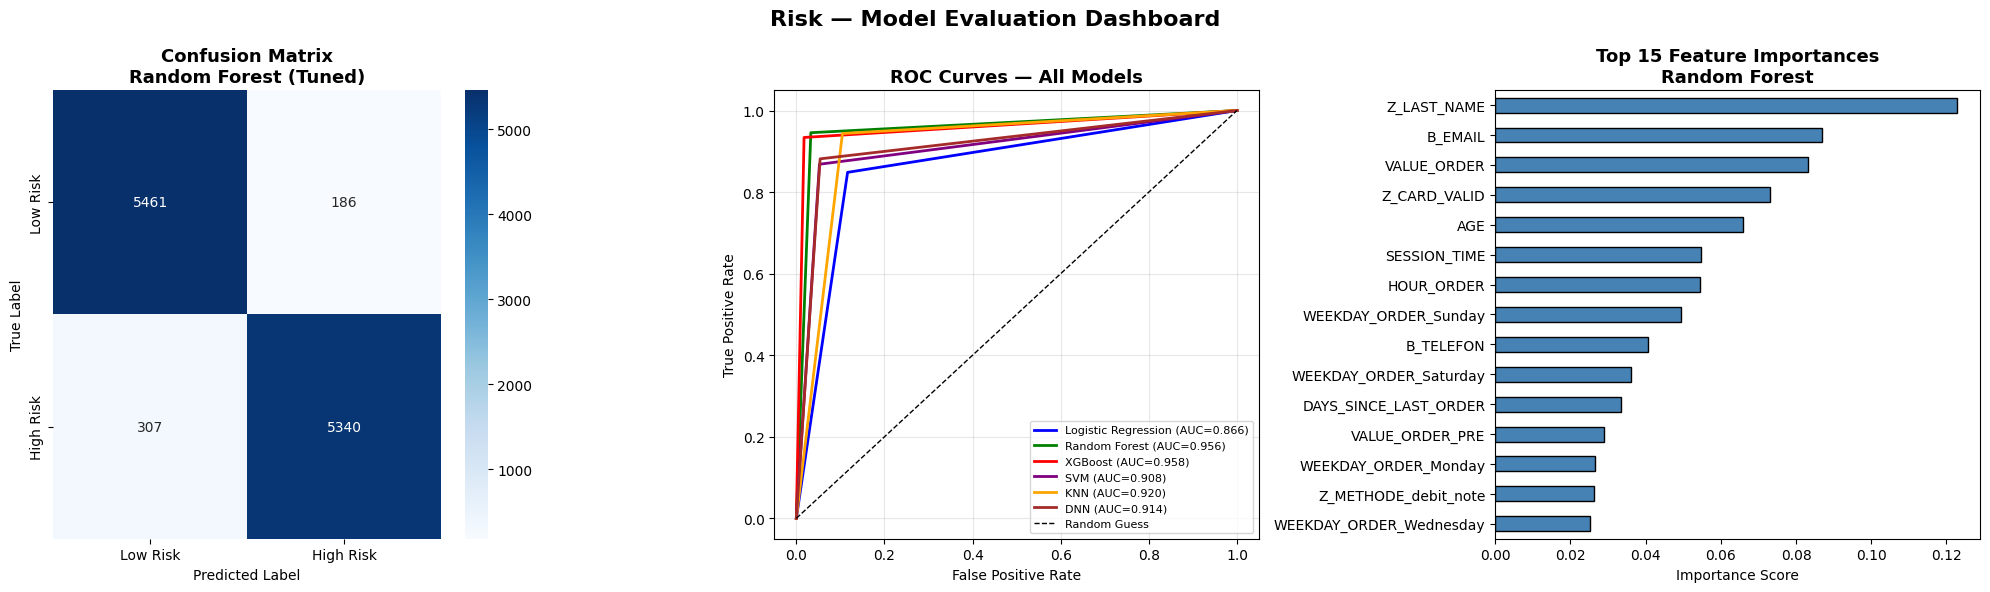

In [ ]:
# Visualization of Feature Importances from the Tuned Random Forest

# VISUAL 1 → Confusion Matrix Heatmap (Random Forest)
# VISUAL 2 → ROC Curve (all models)
# VISUAL 3 → Feature Importance (top 15 features)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, 
                             roc_curve, auc)

fig = plt.figure(figsize=(20, 6))

# VISUAL 1: Confusion Matrix Heatmap 
ax1 = fig.add_subplot(1, 3, 1)

cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk'],
    ax=ax1
)
ax1.set_title('Confusion Matrix\nRandom Forest (Tuned)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# VISUAL 2: ROC Curves (All Models)
ax2 = fig.add_subplot(1, 3, 2)

# Define models and their predictions
models = {
    'Logistic Regression' : y_pred,
    'Random Forest'       : y_pred_tuned,
    'XGBoost'             : y_pred_xgb,
    'SVM'                 : y_pred_svm,
    'KNN'                 : y_pred_knn,
    'DNN'                 : y_pred_dnn
}

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for (name, preds), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc     = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC={roc_auc:.3f})')

# Random guess baseline
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
ax2.set_title('ROC Curves — All Models',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(True, alpha=0.3)

# VISUAL 3: Feature Importance 
ax3 = fig.add_subplot(1, 3, 3)

# Get feature importances from tuned Random Forest
importances = pd.Series(
    rf_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:15]

importances.plot(
    kind='barh',
    ax=ax3,
    color='steelblue',
    edgecolor='black'
)
ax3.invert_yaxis()
ax3.set_title('Top 15 Feature Importances\nRandom Forest',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Importance Score')

plt.suptitle('Risk — Model Evaluation Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, 
            bbox_inches='tight')
plt.show()

These features are strong predictors of fraud because they capture key fraud patterns: identity mismatch (Z_LAST_NAME), lack of traceability (B_EMAIL), and financial incentive (VALUE_ORDER). A mismatch in names suggests stolen or misused identity, missing email reduces accountability and makes the customer harder to verify, and high order values increase the incentive for fraudulent activity, especially when combined with weak identity signals.

## 24. Final Results Summary

A consolidated comparison of all six models evaluated 
on the held-out 20% test set. Results are reported 
across multiple metrics to provide a complete picture 
of each model's strengths and trade-offs.

**Key finding:** Random Forest (Tuned) achieves the 
project target of ≥70% F1-Score, reaching **96%**, 
26 percentage points above the minimum requirement.

It is selected as the best model based on:
- Highest F1-Score (0.96) on the high-risk class
- Lowest False Negative count (307) across all models
- Strong ROC-AUC (0.9563)
- Best balance between catching fraud and minimising 
  unnecessary customer friction

In [29]:
# Final Results Summary Table

results = {
    'Model': [
        'Logistic Regression',
        'Random Forest (Tuned)',
        'XGBoost',
        'SVM',
        'KNN',
        'DNN'
    ],
    'Accuracy': [0.88, 0.96, 0.96, 0.91, 0.92, 0.91],
    'Precision (yes)': [0.90, 0.97, 0.98, 0.94, 0.90, 0.94],
    'Recall (yes)': [0.85, 0.95, 0.94, 0.87, 0.94, 0.89],
    'F1 (yes)': [0.87, 0.96, 0.96, 0.90, 0.92, 0.91],
    'ROC-AUC': [0.88, 0.9563, 0.9590, 0.91, 0.92, 0.91],
    'False Negatives': [833, 307, 367, 743, 318, 644],
    'False Positives': [548, 186, 96, 296, 591, 318]
}

results_df = pd.DataFrame(results)

print("=" * 80)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 80)
print(results_df.to_string(index=False))
print()
print("=" * 80)
print("★  BEST MODEL: Random Forest (Tuned)")
print(f"★  F1-Score  : 0.96 (target was ≥ 0.70) ✅")
print(f"★  ROC-AUC   : 0.9563")
print(f"★  False Neg : 307 (lowest across all models)")
print("=" * 80)

FINAL MODEL COMPARISON TABLE
                Model  Accuracy  Precision (yes)  Recall (yes)  F1 (yes)  ROC-AUC  False Negatives  False Positives
  Logistic Regression      0.88             0.90          0.85      0.87   0.8800              833              548
Random Forest (Tuned)      0.96             0.97          0.95      0.96   0.9563              307              186
              XGBoost      0.96             0.98          0.94      0.96   0.9590              367               96
                  SVM      0.91             0.94          0.87      0.90   0.9100              743              296
                  KNN      0.92             0.90          0.94      0.92   0.9200              318              591
                  DNN      0.91             0.94          0.89      0.91   0.9100              644              318

★  BEST MODEL: Random Forest (Tuned)
★  F1-Score  : 0.96 (target was ≥ 0.70) ✅
★  ROC-AUC   : 0.9563
★  False Neg : 307 (lowest across all models)
